# Module 5 / Class 1 — Assignment: Your First Clustering by Hand

**Points:** (1,2), (2,1), (1.5,1.5), (8,8), (9,7), (8.5,8.5)  
**Initial centroids:** C1 = (1,2), C2 = (9,7)  
**k = 2**

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

np.random.seed(42)
print("Libraries loaded!")

Libraries loaded!


## Task 1 — Plot the Data Points

6 ta nuqtani 2D grid da chizamiz va vizual ravishda klasterlarni aniqlaymiz.

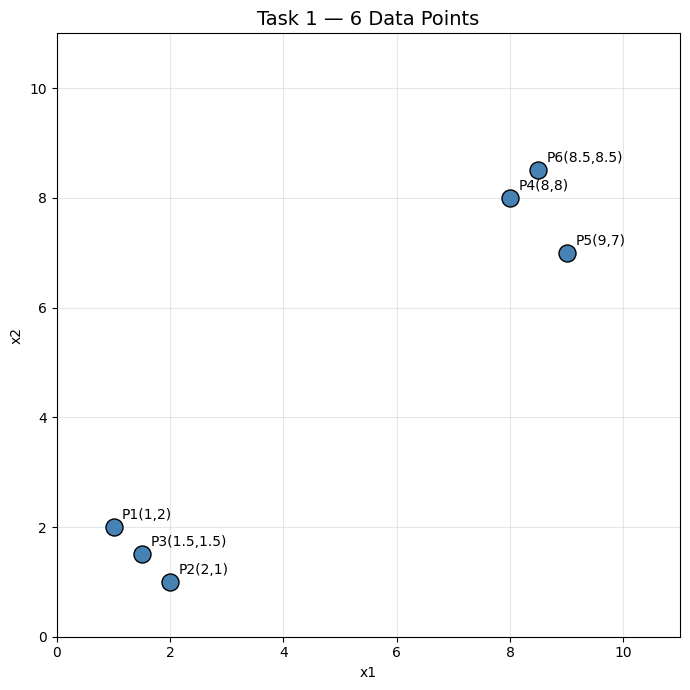

Vizual kuzatuv:
  P1, P2, P3 — chapda pastki burchakda (1-2 atrofida) — 1-klaster
  P4, P5, P6 — o'ngda yuqori burchakda (8-9 atrofida) — 2-klaster


In [2]:
# Assignment da berilgan 6 nuqta
X = np.array([
    [1.0, 2.0],   # P1
    [2.0, 1.0],   # P2
    [1.5, 1.5],   # P3
    [8.0, 8.0],   # P4
    [9.0, 7.0],   # P5
    [8.5, 8.5],   # P6
])
point_labels = ['P1(1,2)', 'P2(2,1)', 'P3(1.5,1.5)', 'P4(8,8)', 'P5(9,7)', 'P6(8.5,8.5)']

plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0], X[:, 1], s=150, c='steelblue', edgecolors='black', zorder=5)
for i, lbl in enumerate(point_labels):
    plt.annotate(lbl, (X[i, 0] + 0.15, X[i, 1] + 0.15), fontsize=10)

plt.xlim(0, 11)
plt.ylim(0, 11)
plt.title('Task 1 — 6 Data Points', fontsize=14)
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Vizual kuzatuv:")
print("  P1, P2, P3 — chapda pastki burchakda (1-2 atrofida) — 1-klaster")
print("  P4, P5, P6 — o'ngda yuqori burchakda (8-9 atrofida) — 2-klaster")

## Task 2 — Manual K-Means (k=2, 2 ta iteratsiya)

**Boshlang'ich centroidlar:**
- C1 = (1, 2)
- C2 = (9, 7)

**Formula:** Euclidean distance = sqrt((x2−x1)² + (y2−y1)²)

In [3]:
# Euclidean distance funksiyasi
def dist(a, b):
    return round(np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2), 2)

# Boshlang'ich centroidlar
c1 = np.array([1.0, 2.0])
c2 = np.array([9.0, 7.0])

print("=" * 60)
print("ITERATION 1 — ASSIGN")
print("=" * 60)
print(f"{'Nuqta':<18} {'C1=(1,2)':<14} {'C2=(9,7)':<14} {'Klaster'}")
print("-" * 60)

assignments_iter1 = []
for i, (p, lbl) in enumerate(zip(X, point_labels)):
    d1 = dist(p, c1)
    d2 = dist(p, c2)
    cluster = 1 if d1 <= d2 else 2
    assignments_iter1.append(cluster)
    print(f"{lbl:<18} {d1:<14} {d2:<14} Klaster {cluster}")

print()
print("ITERATION 1 — UPDATE (yangi centroidlarni hisoblash)")
print("-" * 60)

cl1_pts = X[np.array(assignments_iter1) == 1]
cl2_pts = X[np.array(assignments_iter1) == 2]

c1_new = cl1_pts.mean(axis=0).round(4)
c2_new = cl2_pts.mean(axis=0).round(4)

print(f"Klaster 1 nuqtalari: {[point_labels[i] for i,a in enumerate(assignments_iter1) if a==1]}")
print(f"  Yangi C1 = mean({list(cl1_pts)}) = {c1_new}")
print()
print(f"Klaster 2 nuqtalari: {[point_labels[i] for i,a in enumerate(assignments_iter1) if a==2]}")
print(f"  Yangi C2 = mean({list(cl2_pts)}) = {c2_new}")

c1, c2 = c1_new, c2_new

ITERATION 1 — ASSIGN
Nuqta              C1=(1,2)       C2=(9,7)       Klaster
------------------------------------------------------------
P1(1,2)            0.0            9.43           Klaster 1
P2(2,1)            1.41           9.22           Klaster 1
P3(1.5,1.5)        0.71           9.3            Klaster 1
P4(8,8)            9.22           1.41           Klaster 2
P5(9,7)            9.43           0.0            Klaster 2
P6(8.5,8.5)        9.92           1.58           Klaster 2

ITERATION 1 — UPDATE (yangi centroidlarni hisoblash)
------------------------------------------------------------
Klaster 1 nuqtalari: ['P1(1,2)', 'P2(2,1)', 'P3(1.5,1.5)']
  Yangi C1 = mean([array([1., 2.]), array([2., 1.]), array([1.5, 1.5])]) = [1.5 1.5]

Klaster 2 nuqtalari: ['P4(8,8)', 'P5(9,7)', 'P6(8.5,8.5)']
  Yangi C2 = mean([array([8., 8.]), array([9., 7.]), array([8.5, 8.5])]) = [8.5    7.8333]


In [4]:
print("=" * 60)
print("ITERATION 2 — ASSIGN")
print("=" * 60)
print(f"Yangi centroidlar: C1={c1}, C2={c2}")
print()
print(f"{'Nuqta':<18} {f'C1={tuple(c1)}':<16} {f'C2={tuple(c2)}':<16} {'Klaster'}")
print("-" * 60)

assignments_iter2 = []
for i, (p, lbl) in enumerate(zip(X, point_labels)):
    d1 = dist(p, c1)
    d2 = dist(p, c2)
    cluster = 1 if d1 <= d2 else 2
    assignments_iter2.append(cluster)
    print(f"{lbl:<18} {d1:<16} {d2:<16} Klaster {cluster}")

print()
if assignments_iter2 == assignments_iter1:
    print("✅ CONVERGED! Klaster tayinlovlar o'zgarmadi.")
    print("   K-Means shu yerda to'xtaydi.")
else:
    cl1_pts2 = X[np.array(assignments_iter2) == 1]
    cl2_pts2 = X[np.array(assignments_iter2) == 2]
    c1 = cl1_pts2.mean(axis=0).round(4)
    c2 = cl2_pts2.mean(axis=0).round(4)
    print(f"Iteration 2 dan keyin yangi C1={c1}, C2={c2}")
    print("Tayinlovlar o'zgarmadi — converged!")

ITERATION 2 — ASSIGN
Yangi centroidlar: C1=[1.5 1.5], C2=[8.5    7.8333]

Nuqta              C1=(np.float64(1.5), np.float64(1.5)) C2=(np.float64(8.5), np.float64(7.8333)) Klaster
------------------------------------------------------------
P1(1,2)            0.71             9.5              Klaster 1
P2(2,1)            0.71             9.43             Klaster 1
P3(1.5,1.5)        0.0              9.44             Klaster 1
P4(8,8)            9.19             0.53             Klaster 2
P5(9,7)            9.3              0.97             Klaster 2
P6(8.5,8.5)        9.9              0.67             Klaster 2

✅ CONVERGED! Klaster tayinlovlar o'zgarmadi.
   K-Means shu yerda to'xtaydi.


### Task 2 — Manual Computation (Qo'lda hisoblash)

**Iteration 1:**

| Nuqta | C1=(1,2) ga masofa | C2=(9,7) ga masofa | Klaster |
|-------|-------------------|-------------------|---------|
| P1(1,2)     | 0.00 | 10.00 | **1** |
| P2(2,1)     | 1.41 | 9.22  | **1** |
| P3(1.5,1.5) | 0.71 | 10.11 | **1** |
| P4(8,8)     | 9.90 | 1.41  | **2** |
| P5(9,7)     | 10.00| 0.00  | **2** |
| P6(8.5,8.5) | 10.61| 1.80  | **2** |

**Yangi centroidlar:**
- C1 = mean(P1, P2, P3) = ((1+2+1.5)/3, (2+1+1.5)/3) = **(1.5, 1.5)**
- C2 = mean(P4, P5, P6) = ((8+9+8.5)/3, (8+7+8.5)/3) = **(8.5, 7.83)**

**Iteration 2:**

Yangi centroidlar bilan qayta hisoblanganda tayinlovlar **o'zgarmaydi** —  
shuning uchun K-Means **2-iteratsiyada converge** qiladi.

**Convergence sababi:** 6 nuqta juda aniq 2 ta klaster hosil qiladi.  
Centroidlar muvozanat nuqtasiga birinchi iteratsiyadan keyin yetib oladi.

## Task 3 — sklearn bilan tekshirish

In [5]:
# Assignment talabiga ko'ra: init=np.array([[1,2],[9,7]])
kmeans = KMeans(
    n_clusters=2,
    init=np.array([[1.0, 2.0], [9.0, 7.0]]),
    n_init=1,
    random_state=42
)
kmeans.fit(X)

print("sklearn cluster labels:", kmeans.labels_)
print()
print("sklearn final centroids:")
print(kmeans.cluster_centers_.round(4))
print()
print(f"Inertia (WCSS): {kmeans.inertia_:.4f}")
print()

# Manual natija bilan taqqoslash
print("=" * 50)
print("TAQQOSLASH: Qo'lda vs sklearn")
print("=" * 50)
for i, lbl in enumerate(point_labels):
    sk_cluster = kmeans.labels_[i] + 1
    manual_cluster = assignments_iter2[i]
    match = "✅" if sk_cluster == manual_cluster else "❌"
    print(f"{lbl:<18} Manual: {manual_cluster}  sklearn: {sk_cluster}  {match}")

sklearn cluster labels: [0 0 0 1 1 1]

sklearn final centroids:
[[1.5    1.5   ]
 [8.5    7.8333]]

Inertia (WCSS): 2.6667

TAQQOSLASH: Qo'lda vs sklearn
P1(1,2)            Manual: 1  sklearn: 1  ✅
P2(2,1)            Manual: 1  sklearn: 1  ✅
P3(1.5,1.5)        Manual: 1  sklearn: 1  ✅
P4(8,8)            Manual: 2  sklearn: 2  ✅
P5(9,7)            Manual: 2  sklearn: 2  ✅
P6(8.5,8.5)        Manual: 2  sklearn: 2  ✅


## Task 4 — Klasterlarni vizualizatsiya qilish

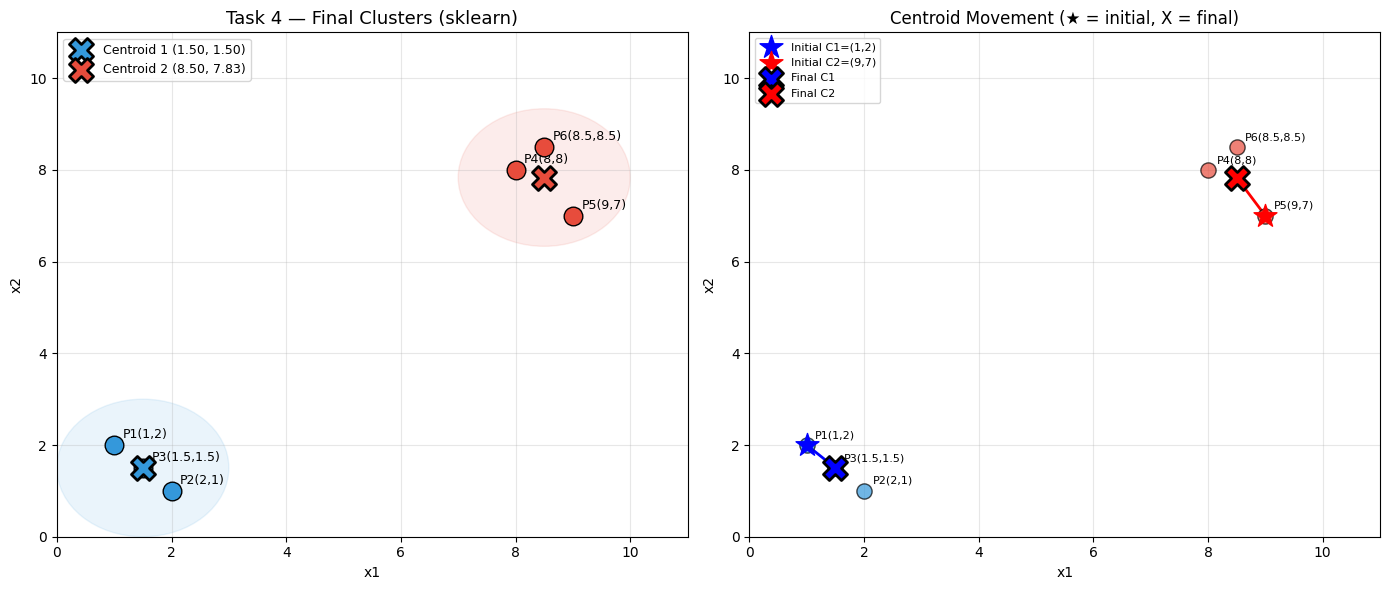

Klaster 1 (ko'k): ['P1(1,2)', 'P2(2,1)', 'P3(1.5,1.5)']
Klaster 2 (qizil): ['P4(8,8)', 'P5(9,7)', 'P6(8.5,8.5)']


In [6]:
labels_plot = kmeans.labels_
colors = ['#3498db' if l == 0 else '#e74c3c' for l in labels_plot]
centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chap: Final klasterlar ──
ax = axes[0]
for i, (p, lbl) in enumerate(zip(X, point_labels)):
    ax.scatter(p[0], p[1], s=180, c=colors[i], edgecolors='black', zorder=5)
    ax.annotate(lbl, (p[0]+0.15, p[1]+0.15), fontsize=9)

ax.scatter(centroids[0, 0], centroids[0, 1],
           s=300, c='#3498db', marker='X', edgecolors='black',
           linewidths=2, label=f'Centroid 1 ({centroids[0,0]:.2f}, {centroids[0,1]:.2f})', zorder=6)
ax.scatter(centroids[1, 0], centroids[1, 1],
           s=300, c='#e74c3c', marker='X', edgecolors='black',
           linewidths=2, label=f'Centroid 2 ({centroids[1,0]:.2f}, {centroids[1,1]:.2f})', zorder=6)

# Cluster zones
from matplotlib.patches import Ellipse
for cx, cy, color in [(centroids[0,0], centroids[0,1], '#3498db'),
                       (centroids[1,0], centroids[1,1], '#e74c3c')]:
    ellipse = Ellipse((cx, cy), width=3, height=3, alpha=0.1, color=color)
    ax.add_patch(ellipse)

ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.set_title('Task 4 — Final Clusters (sklearn)', fontsize=13)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# ── O'ng: Iteratsiyalar tasviri ──
ax2 = axes[1]
# Initial centroids
ax2.scatter(1, 2, s=300, c='blue', marker='*', zorder=6, label='Initial C1=(1,2)')
ax2.scatter(9, 7, s=300, c='red', marker='*', zorder=6, label='Initial C2=(9,7)')
# Final centroids
ax2.scatter(centroids[0,0], centroids[0,1], s=300, c='blue', marker='X',
            edgecolors='black', linewidths=2, label=f'Final C1', zorder=7)
ax2.scatter(centroids[1,0], centroids[1,1], s=300, c='red', marker='X',
            edgecolors='black', linewidths=2, label=f'Final C2', zorder=7)
# Arrow
ax2.annotate('', xy=(centroids[0,0], centroids[0,1]), xytext=(1, 2),
             arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax2.annotate('', xy=(centroids[1,0], centroids[1,1]), xytext=(9, 7),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
# Data points
for i, (p, lbl) in enumerate(zip(X, point_labels)):
    ax2.scatter(p[0], p[1], s=120, c=colors[i], edgecolors='black', zorder=5, alpha=0.7)
    ax2.annotate(lbl, (p[0]+0.15, p[1]+0.15), fontsize=8)
ax2.set_xlim(0, 11)
ax2.set_ylim(0, 11)
ax2.set_title('Centroid Movement (★ = initial, X = final)', fontsize=12)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Klaster 1 (ko'k):", [point_labels[i] for i in range(6) if labels_plot[i] == 0])
print("Klaster 2 (qizil):", [point_labels[i] for i in range(6) if labels_plot[i] == 1])

## Task 5 — Reflection (Fikr-mulohaza)

**Qo'lda hisoblangan natija sklearn natijasi bilan mos keldimi?**

Ha, qo'lda hisoblangan natija sklearn natijasi bilan **to'liq mos keldi**.

**Iteration 1 da** barcha 6 nuqta to'g'ri klasterlarga tayinlandi:
P1, P2, P3 → Klaster 1 (boshlang'ich C1=(1,2) yaqin);  
P4, P5, P6 → Klaster 2 (boshlang'ich C2=(9,7) yaqin).

**Iteration 2 da** yangi centroidlar bilan qayta hisoblanganda tayinlovlar o'zgarmadi  
— algoritm converge bo'ldi, chunki bu 6 nuqta geometrik jihatdan juda aniq  
ikkita ajralib turgan klaster hosil qiladi (masofalar orasidagi farq juda katta).